<a href="https://colab.research.google.com/github/sarkarpragati/Machine-Learning-Lab/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Principal Component Analysis (PCA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Copy of IRIS.csv')

In [19]:
X = iris.data
y = iris.target

print("Original Shape of Dataset :", X.shape)

Original Shape of Dataset : (150, 4)


In [7]:
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X = df[features].values
X_scaled = StandardScaler().fit_transform(X)
cov_matrix = np.cov(X_scaled.T)

print("\nCovariance Matrix :\n")
print(cov_matrix)


Covariance Matrix :

[[ 1.00671141 -0.11010327  0.87760486  0.82344326]
 [-0.11010327  1.00671141 -0.42333835 -0.358937  ]
 [ 0.87760486 -0.42333835  1.00671141  0.96921855]
 [ 0.82344326 -0.358937    0.96921855  1.00671141]]


In [8]:
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

print("\nEigen Values :\n")
print(eigen_values)

print("\nEigen Vectors :\n")
print(eigen_vectors)



Eigen Values :

[2.93035378 0.92740362 0.14834223 0.02074601]

Eigen Vectors :

[[ 0.52237162 -0.37231836 -0.72101681  0.26199559]
 [-0.26335492 -0.92555649  0.24203288 -0.12413481]
 [ 0.58125401 -0.02109478  0.14089226 -0.80115427]
 [ 0.56561105 -0.06541577  0.6338014   0.52354627]]


In [9]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nShape After PCA :", X_pca.shape)

print("\nReduced Dataset :\n")
print(X_pca[:5])


Shape After PCA : (150, 2)

Reduced Dataset :

[[-2.26454173  0.5057039 ]
 [-2.0864255  -0.65540473]
 [-2.36795045 -0.31847731]
 [-2.30419716 -0.57536771]
 [-2.38877749  0.6747674 ]]


In [10]:
print("\nExplained Variance Ratio :")
print(pca.explained_variance_ratio_)


Explained Variance Ratio :
[0.72770452 0.23030523]


Text(0.5, 1.0, 'Original Data')

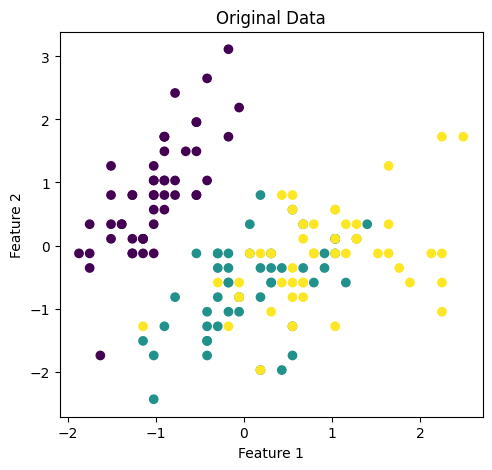

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
y, _ = pd.factorize(df['Species'])
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Data")

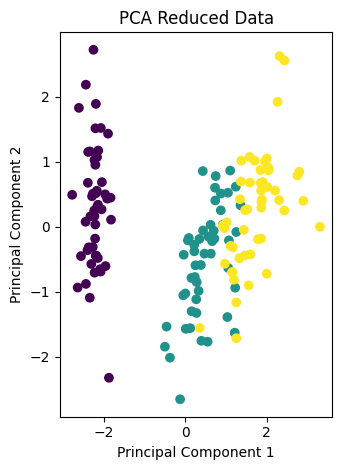

In [13]:
plt.subplot(1,2,2)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Reduced Data")

plt.tight_layout()
plt.show()

Convert Decision Tree in to “If then else Rules”

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import export_text
from sklearn.model_selection import train_test_split


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
df = pd.read_csv('/content/drive/MyDrive/Copy of IRIS.csv')

In [18]:
iris = load_iris()
X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

print("Features:\n")
print(feature_names)

print("\nClasses:\n")
print(class_names)

Features:

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes:

['setosa' 'versicolor' 'virginica']


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [21]:
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("\nDecision Tree Model Trained Successfully")


Decision Tree Model Trained Successfully


In [22]:
accuracy = model.score(X_test, y_test)

print("\nAccuracy :", accuracy)


Accuracy : 1.0


In [23]:
rules = export_text(
    model,
    feature_names=list(feature_names)
)

print("\nIF-THEN RULES:\n")
print(rules)



IF-THEN RULES:

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



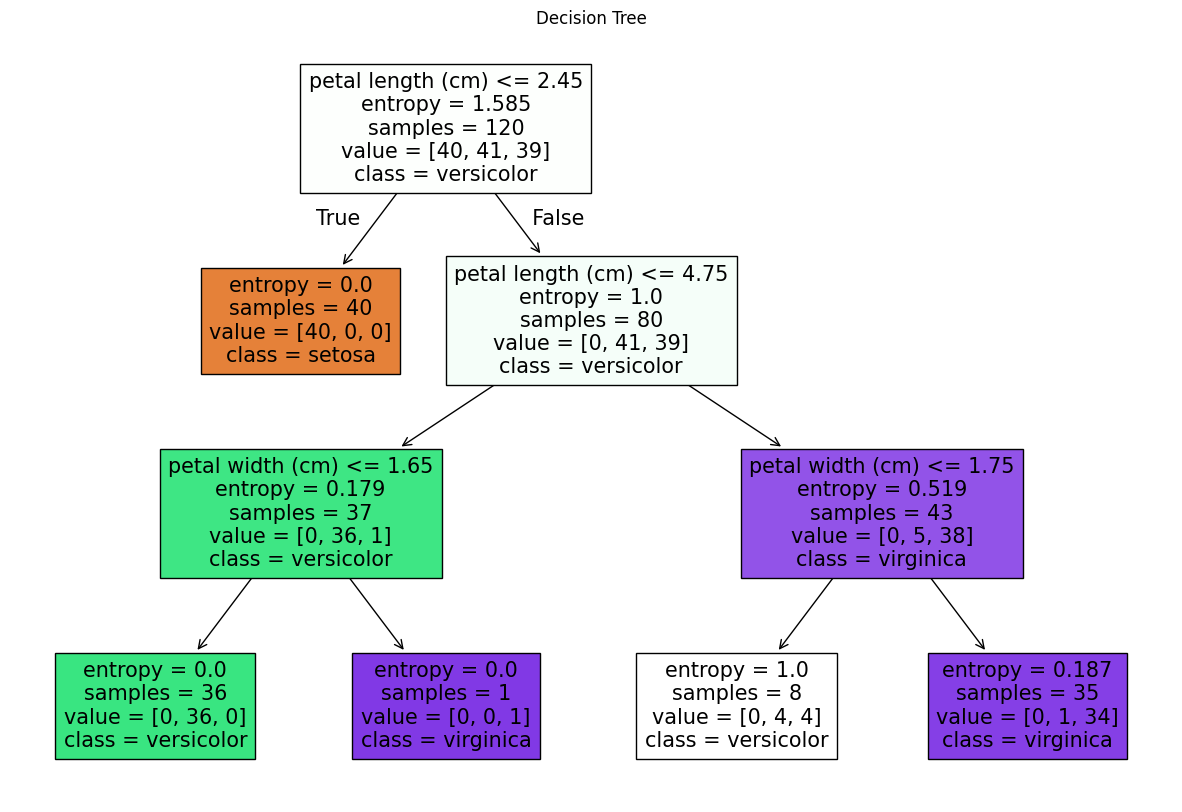

In [24]:
plt.figure(figsize=(15,10))

plot_tree(
    model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True
)

plt.title("Decision Tree")

plt.show()